# Step 1: Import Required Libraries 

In [36]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

# Step 2: Load the Dataset

In [2]:
file_path = "Telco_customer_churn.xlsx"

# Load Excel file 
data = pd.read_excel(file_path)

print("Dataset Loaded")

Dataset Loaded


# Step 3: Explore the Datsaset

In [3]:
# quick peek & basic info about dataset 
print("Shape:", data.shape)

Shape: (7043, 33)


In [4]:
print("Display top 5 rows of dataset")
display(data.head(5))

Display top 5 rows of dataset


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
print("--- Datatypes ---")
display(data.dtypes)

--- Datatypes ---


CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [6]:
print("\n--- Describe dataset (numeric) ---") 
display(data.describe().T)


--- Describe dataset (numeric) ---


,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [7]:
print("\n--- Describe dataset (object / categorical sample) ---")
display(data.describe(include=['object']).T)


--- Describe dataset (object / categorical sample) ---


,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"33.964131, -118.272783",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [8]:
# duplicates values 
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [9]:
# Missing values 
print("Missing rows:\n", data.isnull().sum())

Missing rows:
 CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


# Step 4: Exploratory Data Analysis (EDA) 

### A: Target Variable Distribution

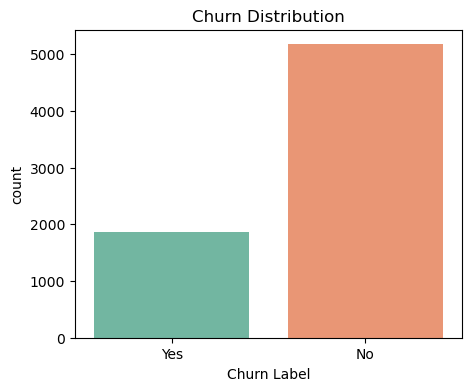

Churn Label
No     0.735
Yes    0.265
Name: proportion, dtype: float64


In [10]:
# Visualize Churn Label (Yes/No)
plt.figure(figsize=(5,4))
sns.countplot(x='Churn Label', data=data, palette='Set2', hue='Churn Label')
plt.title("Churn Distribution")
plt.show()

print(data['Churn Label'].value_counts(normalize=True).round(3))

### B. Numerical Features vs Churn

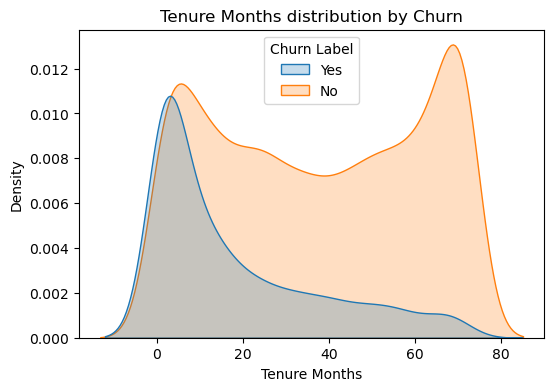

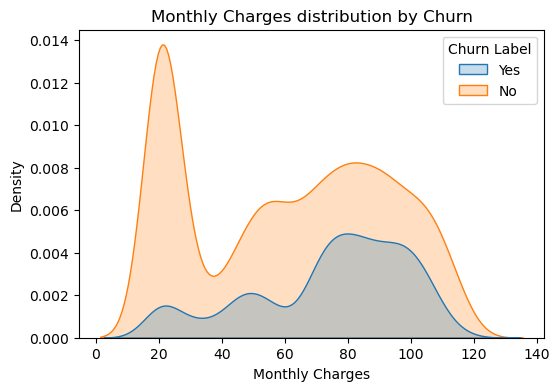

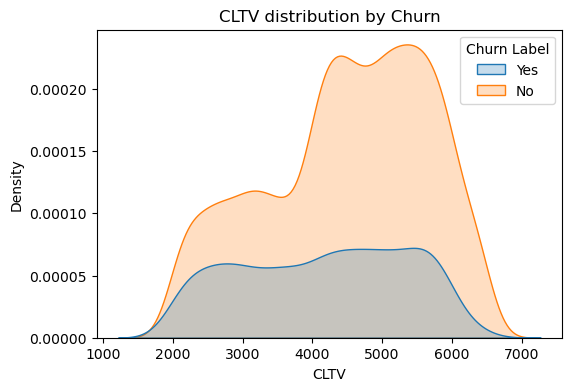

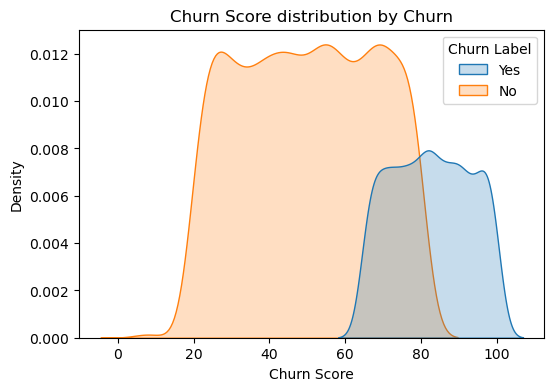

In [11]:
# Visualize Numerical Features such as Tenure Months, Monthly Charges, CLTV on Churn Score.
num_cols = ['Tenure Months', 'Monthly Charges', 'CLTV', 'Churn Score']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=data, x=col, hue='Churn Label', fill=True)
    plt.title(f"{col} distribution by Churn")
    plt.show()

### C. Categorical Features vs Churn

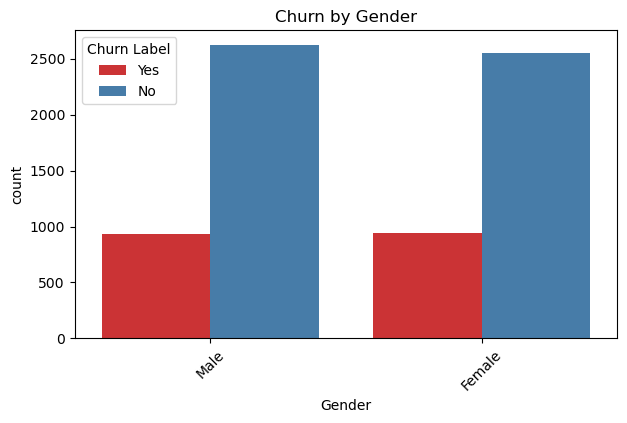

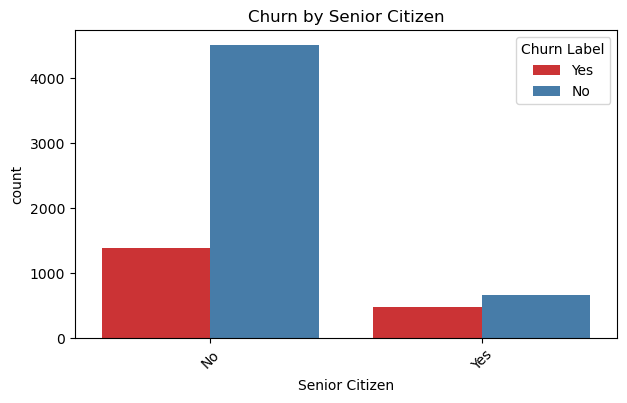

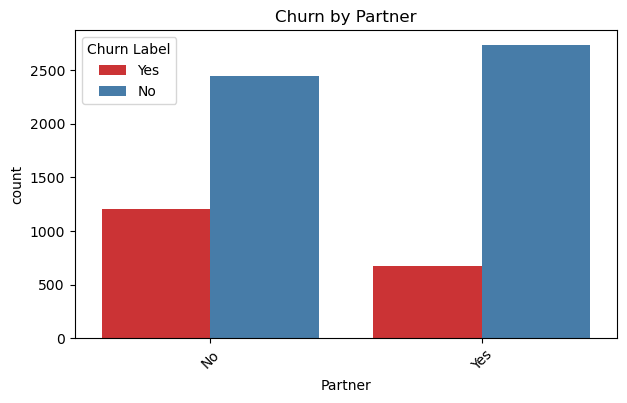

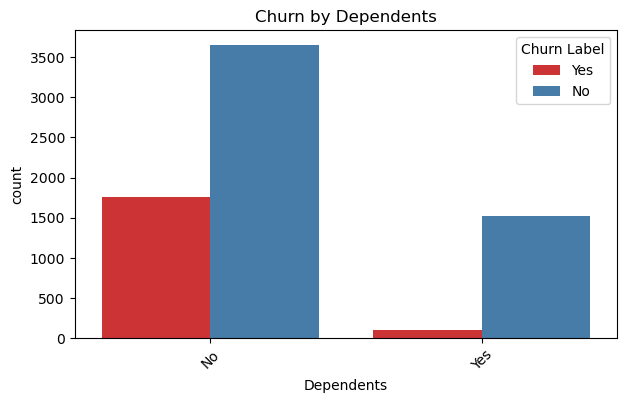

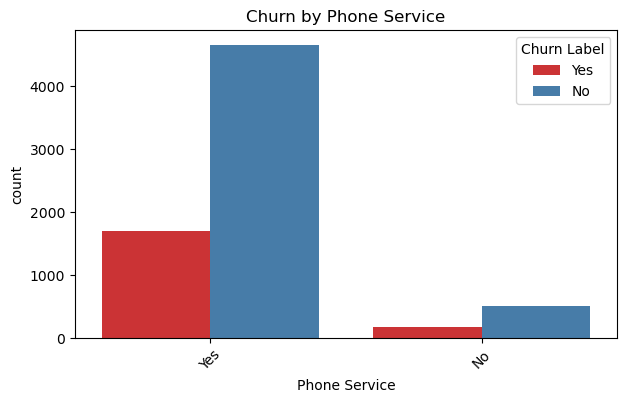

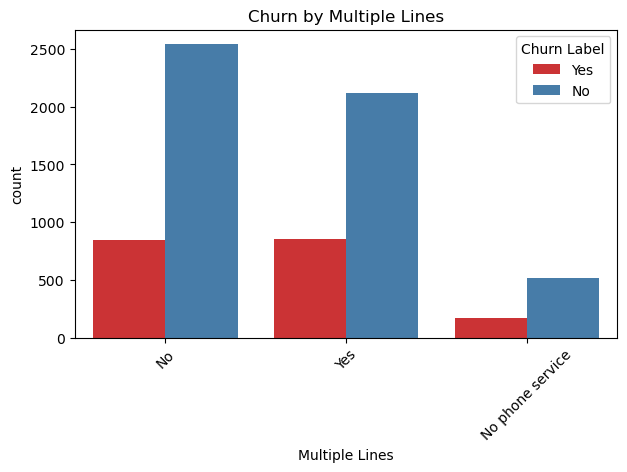

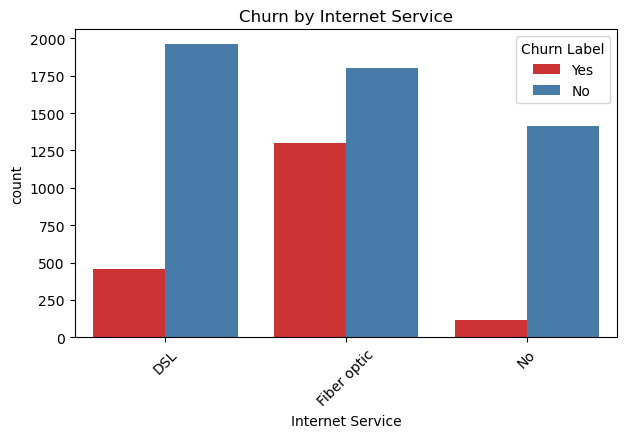

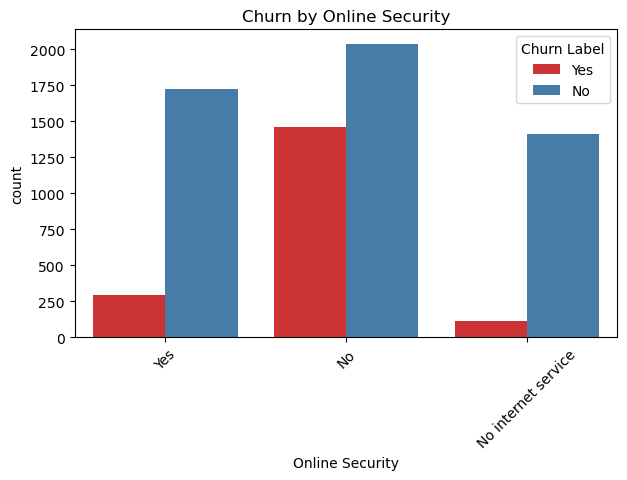

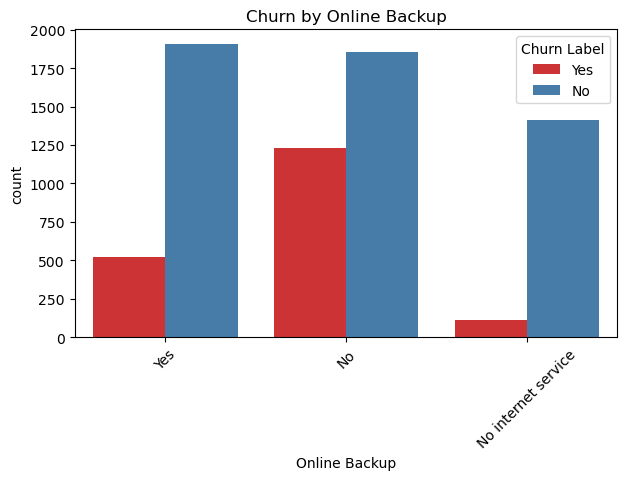

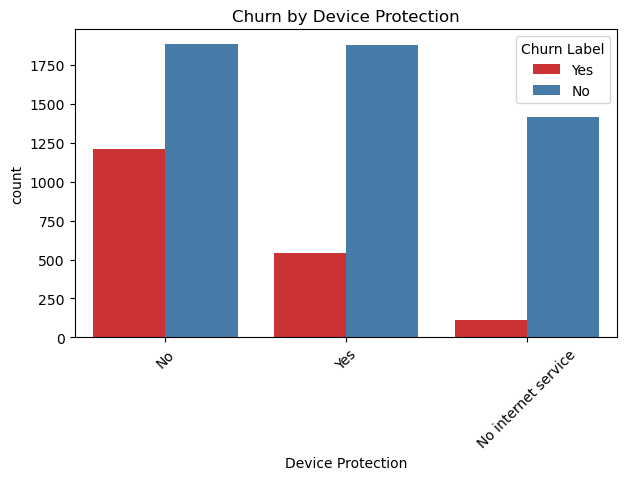

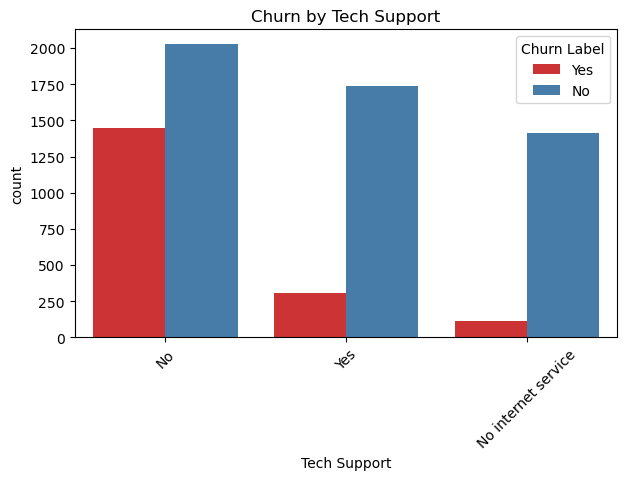

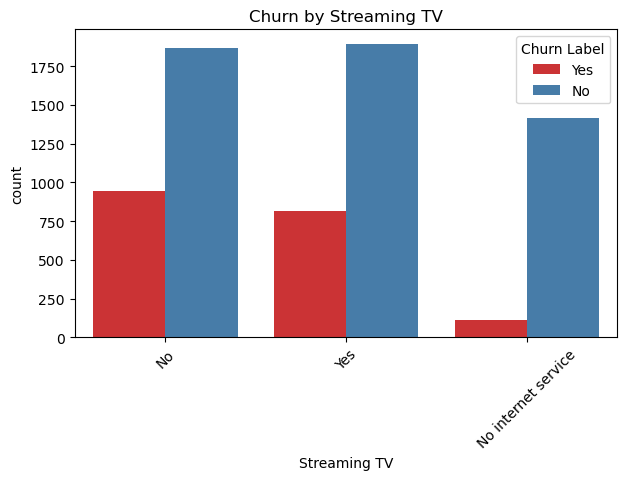

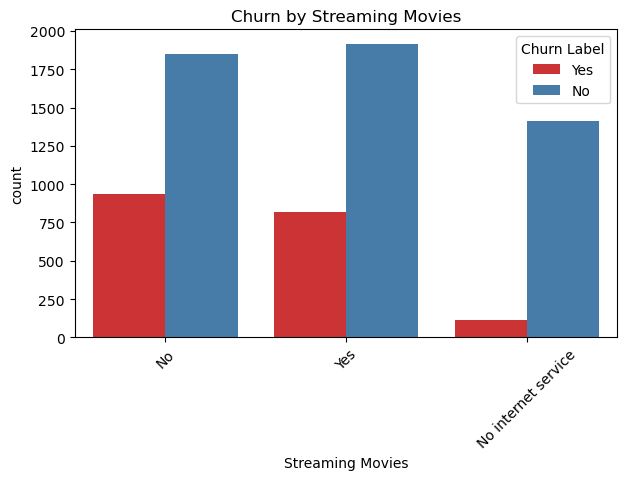

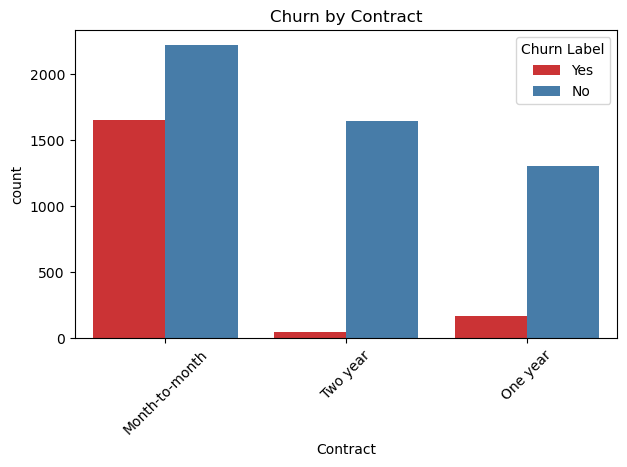

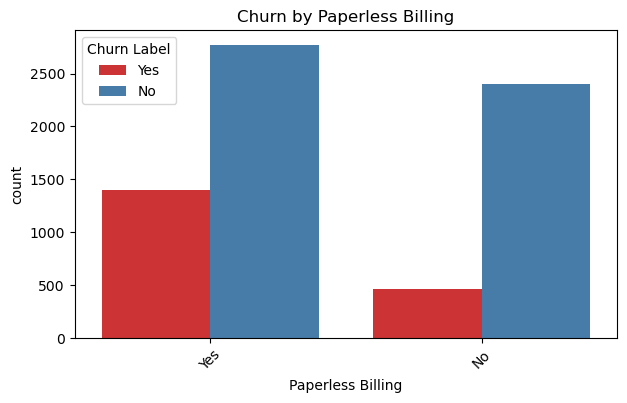

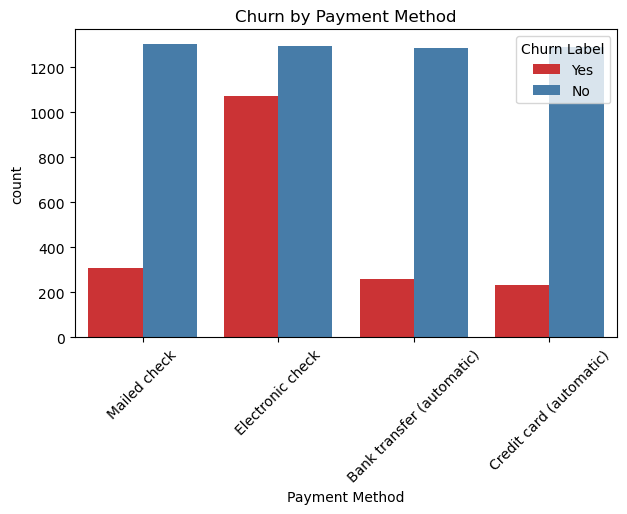

In [12]:
# Visualize Categorical columns on churn Score
cat_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 
            'Phone Service', 'Multiple Lines', 'Internet Service', 
            'Online Security', 'Online Backup', 'Device Protection', 
            'Tech Support', 'Streaming TV', 'Streaming Movies',
            'Contract', 'Paperless Billing', 'Payment Method']

for col in cat_cols:
    if col in data.columns:
        plt.figure(figsize=(7,4))
        sns.countplot(x=col, hue='Churn Label', data=data, palette='Set1')
        plt.title(f"Churn by {col}")
        plt.xticks(rotation=45)
        plt.show()

### D. Churn Rate Heatmaps

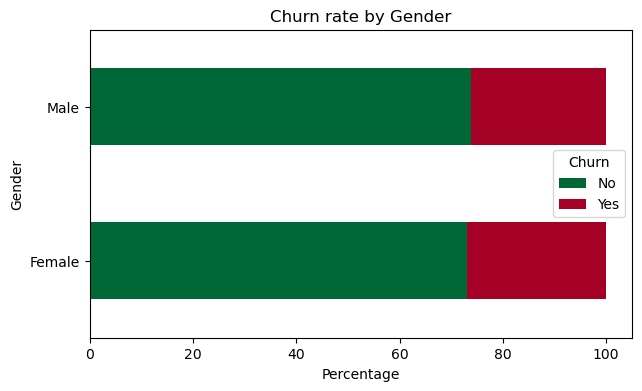

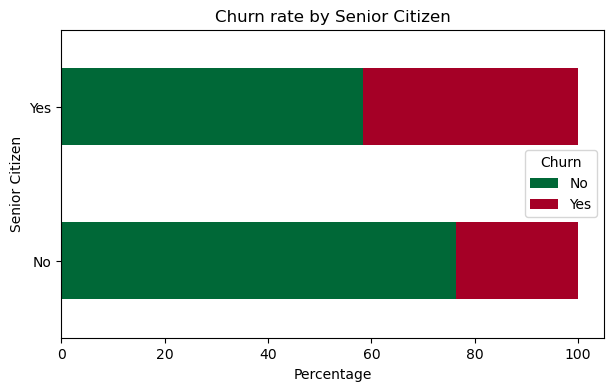

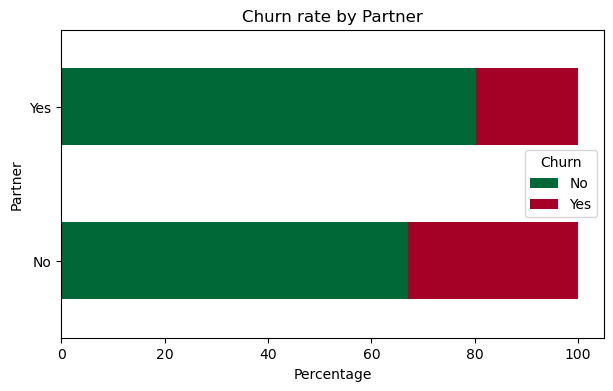

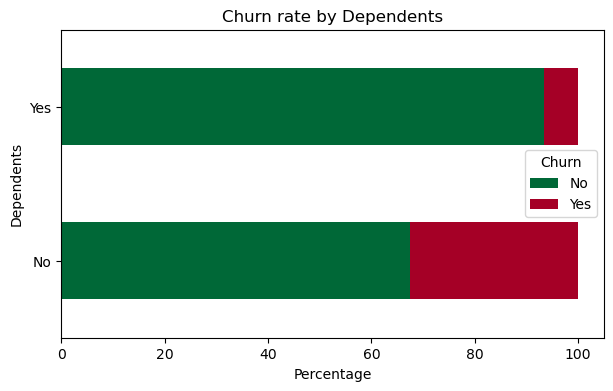

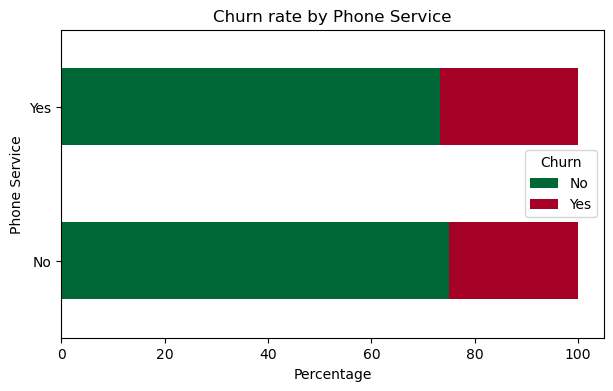

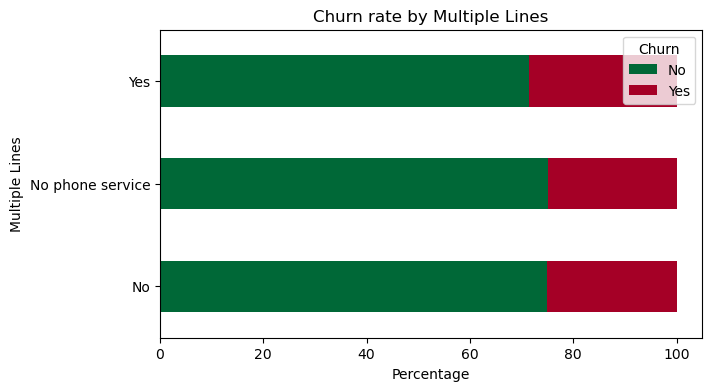

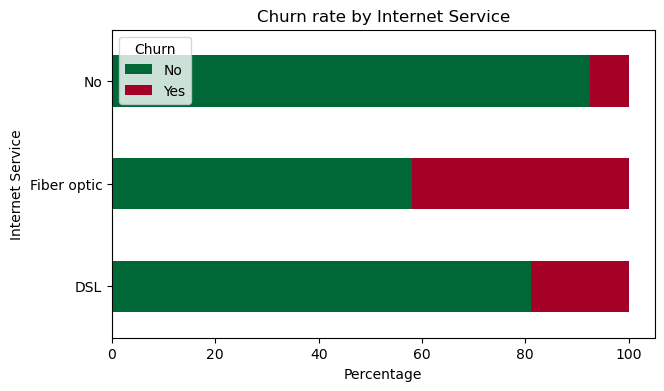

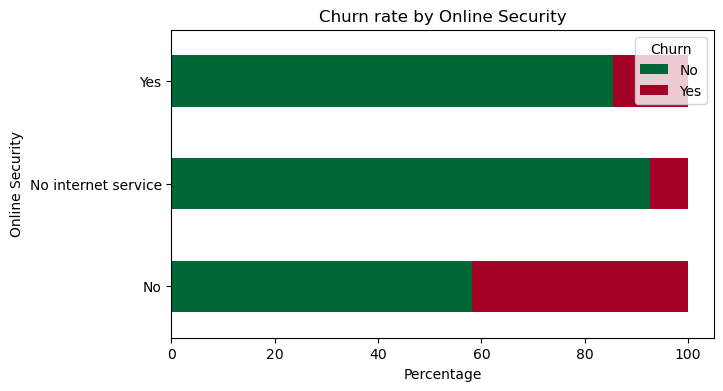

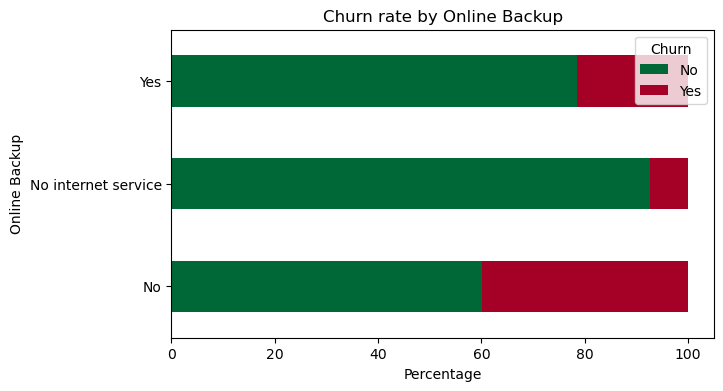

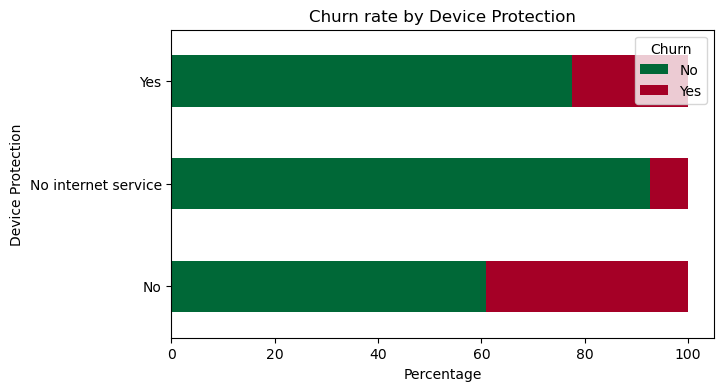

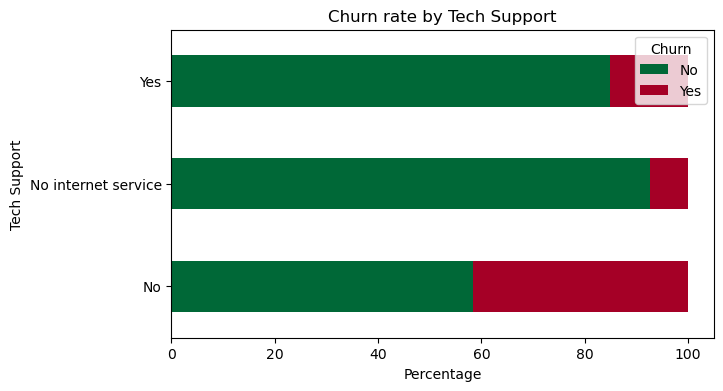

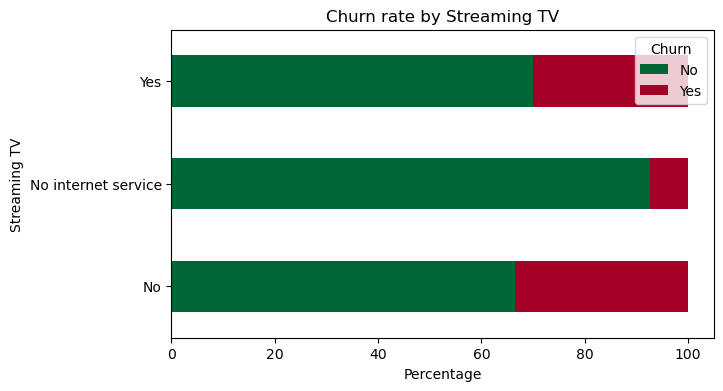

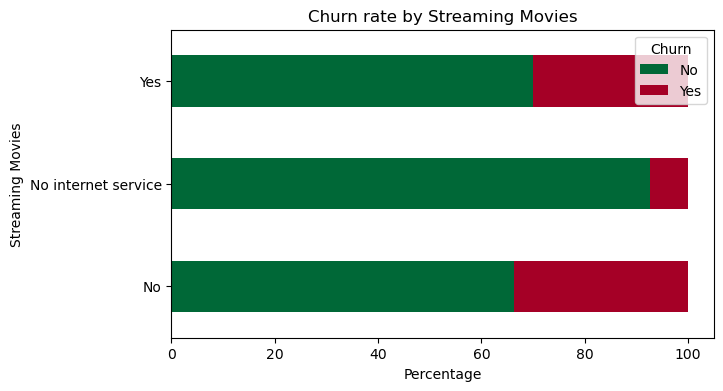

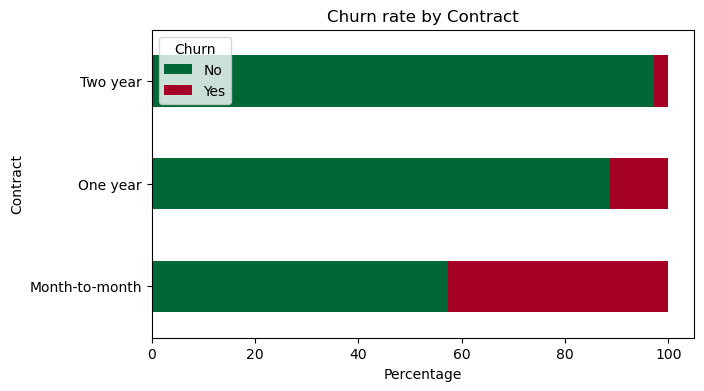

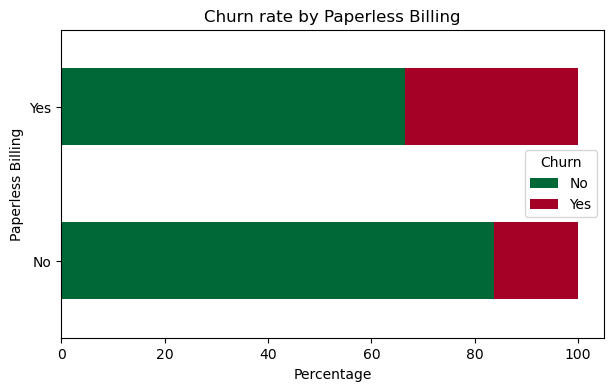

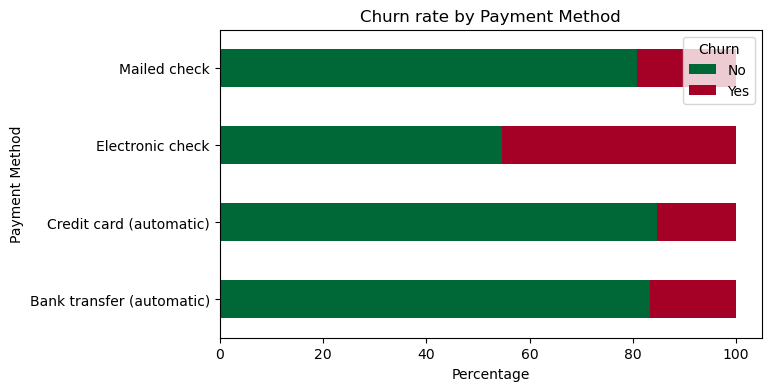

In [13]:
# Show churn percentage by category
for col in cat_cols:
    if col in data.columns:
        churn_rate = pd.crosstab(data[col], data['Churn Label'], normalize='index') * 100
        churn_rate.plot(kind='barh', stacked=True, figsize=(7,4), colormap="RdYlGn_r")
        plt.title(f"Churn rate by {col}")
        plt.xlabel("Percentage")
        plt.legend(title='Churn')
        plt.show()

### E. Correlation (Numerical Features)

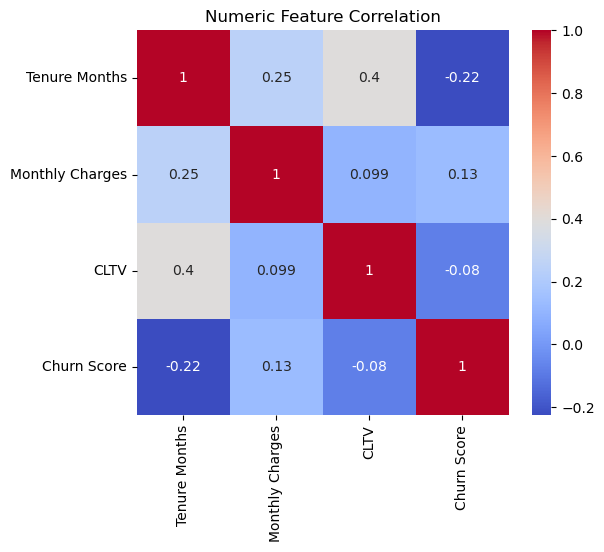

In [14]:
# Check correlations among numeric features.
plt.figure(figsize=(6,5))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Numeric Feature Correlation")
plt.show()

# Step 5: Data Preprocessing

In [15]:
# 1. Drop unnecessary columns
data.drop(columns=['CustomerID', 'Count', 'Lat Long', 'Churn Label', 'Churn Reason'], inplace=True)

In [16]:
# 2. Convert 'Total Charges' to numeric
data['Total Charges'] = pd.to_numeric(data['Total Charges'], errors='coerce')
data['Total Charges'].fillna(data['Total Charges'].median(), inplace=True)  # Fill blanks with median

In [17]:
# 3. Convert binary columns to 0/1
# Gender
data['Gender'] = data['Gender'].map({'Male':1, 'Female':0})

# Binary Yes/No columns
binary_cols = ['Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing']
for col in binary_cols:
    data[col] = data[col].map({'Yes':1, 'No':0})
    data[col].fillna(data[col].mode()[0], inplace=True)

# Check if any column still has nulls after mapping
print(data[binary_cols + ['Gender']].isnull().sum())

Senior Citizen       0
Partner              0
Dependents           0
Phone Service        0
Paperless Billing    0
Gender               0
dtype: int64


In [18]:
# 4. Handle categorical variables (One-Hot Encoding)
categorical_cols = ['Multiple Lines', 'Internet Service', 'Online Security', 
                    'Online Backup', 'Device Protection', 'Tech Support', 
                    'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method', 
                    'Country', 'State', 'City', 'Zip Code']

data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [19]:
# 5. Feature Scaling (Numerical)
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Latitude', 'Longitude']
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

# Step 6: Split Dataset for Training

In [38]:
# Split dataset into X and y
X = data.drop(columns=['Churn Value'])
Y = data['Churn Value']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Shape of X_train: (4930, 2813)
Shape of X_test: (2113, 2813)


In [22]:
# Check which columns have NaNs
nan_cols = X_train.columns[X_train.isnull().any()]
print("Columns with NaN:", nan_cols)

Columns with NaN: Index([], dtype='object')


In [23]:
binary_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing']

# Fill NaNs with the most frequent value (mode) in each column
for col in binary_cols:
    mode_val = X_train[col].mode()[0]  # get mode from train set
    X_train[col].fillna(mode_val, inplace=True)
    X_test[col].fillna(mode_val, inplace=True)

In [24]:
print("Remaining NaNs in X_train:", X_train.isnull().sum().sum())
print("Remaining NaNs in X_test:", X_test.isnull().sum().sum())

Remaining NaNs in X_train: 0
Remaining NaNs in X_test: 0


In [25]:
# Fill numerical columns
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Latitude', 'Longitude']
X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X_train[num_cols].median())  # use train median

# Fill one-hot encoded columns with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Step 7: Model Building and Training

In [34]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
Y_pred = model.predict(X_test)

In [28]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [31]:
# XGBoost
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

# Step 8: Model Evaluation

In [35]:
models = {"Logistic Regression": lr, "Random Forest": rf, "XGBoost": xgb}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    print(f"\n{name} Evaluation:")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
    print("Recall:", round(recall_score(y_test, y_pred), 3))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


Logistic Regression Evaluation:
Accuracy: 0.909
Recall: 0.911
ROC-AUC: 0.974
Confusion Matrix:
 [[1410  142]
 [  50  511]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94      1552
           1       0.78      0.91      0.84       561

    accuracy                           0.91      2113
   macro avg       0.87      0.91      0.89      2113
weighted avg       0.92      0.91      0.91      2113


Random Forest Evaluation:
Accuracy: 0.908
Recall: 0.802
ROC-AUC: 0.957
Confusion Matrix:
 [[1469   83]
 [ 111  450]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      1552
           1       0.84      0.80      0.82       561

    accuracy                           0.91      2113
   macro avg       0.89      0.87      0.88      2113
weighted avg       0.91      0.91      0.91      2113


XGBoost Evaluation:
Accuracy: 0.921
Recall: 0.865
ROC

# Step 9: Save Best Models

In [39]:
# Save trained models 

joblib.dump(models["Logistic Regression"], "logistic_churn_model.pkl")
joblib.dump(models["XGBoost"], "xgboost_churn_model.pkl")

print("\nModels saved successfully!")


Models saved successfully!
